In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train = pd.read_csv("train.csv")

In [ ]:
train.shape

(8693, 14)

In [ ]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [ ]:
train['Transported'].value_counts()

,count
Transported,
True,4378
False,4315


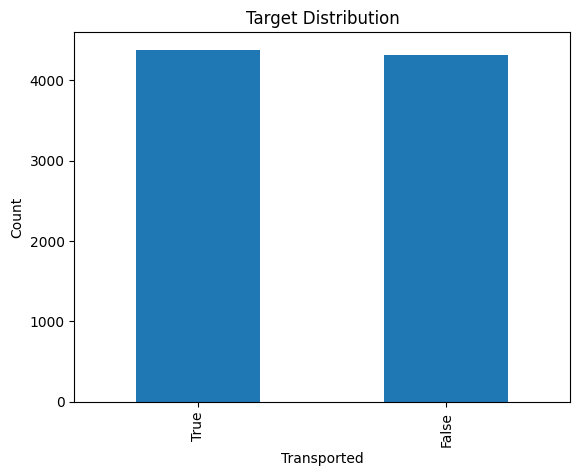

In [ ]:
train['Transported'].value_counts().plot(kind='bar')

plt.title("Target Distribution")
plt.xlabel("Transported")
plt.ylabel("Count")

plt.show()

In [ ]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [ ]:
train.describe(include='object')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,8693,8492,8476,8494,8511,8490,8493
unique,8693,3,2,6560,3,2,8473
top,9280_02,Earth,False,G/734/S,TRAPPIST-1e,False,Ankalik Nateansive
freq,1,4602,5439,8,5915,8291,2


In [ ]:
train.isnull().sum().sort_values(ascending=False)

,0
CryoSleep,217
ShoppingMall,208
VIP,203
HomePlanet,201
Name,200
Cabin,199
VRDeck,188
Spa,183
FoodCourt,183
Destination,182


In [ ]:
missing = train.isnull().sum() / len(train) * 100

missing[missing > 0].sort_values(ascending=False)

,0
CryoSleep,2.496261
ShoppingMall,2.392730
VIP,2.335212
HomePlanet,2.312205
Name,2.300702
Cabin,2.289198
VRDeck,2.162660
FoodCourt,2.105142
Spa,2.105142
Destination,2.093639


In [ ]:
train.duplicated().sum()

np.int64(0)

In [ ]:
train = train.drop_duplicates()

In [ ]:
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = train.select_dtypes(include=['object', 'bool']).columns

In [ ]:
print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='object')

Categorical Columns:
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP',
       'Name', 'Transported'],
      dtype='object')


In [ ]:
for col in numerical_cols:
    train[col] = train[col].fillna(train[col].median())

In [ ]:
for col in categorical_cols:
    train[col] = train[col].fillna(train[col].mode()[0])

/tmp/ipykernel_2236/3153799825.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[col] = train[col].fillna(train[col].mode()[0])


In [ ]:
train.isnull().sum().sum()

np.int64(0)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   object 
 2   CryoSleep     8693 non-null   bool   
 3   Cabin         8693 non-null   object 
 4   Destination   8693 non-null   object 
 5   Age           8693 non-null   float64
 6   VIP           8693 non-null   bool   
 7   RoomService   8693 non-null   float64
 8   FoodCourt     8693 non-null   float64
 9   ShoppingMall  8693 non-null   float64
 10  Spa           8693 non-null   float64
 11  VRDeck        8693 non-null   float64
 12  Name          8693 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(3), float64(6), object(5)
memory usage: 772.7+ KB


## Data Cleaning Observations

- Checked duplicate records.
- Numerical missing values were filled using median.
- Categorical missing values were filled using mode.
- Dataset is ready for feature engineering.


In [ ]:
train_fe = train.copy()

In [ ]:
train_fe[['Deck', 'CabinNum', 'Side']] = train_fe['Cabin'].str.split('/', expand=True)

In [ ]:
train_fe[['Cabin', 'Deck', 'CabinNum', 'Side']].head()

,Cabin,Deck,CabinNum,Side
0,B/0/P,B,0,P
1,F/0/S,F,0,S
2,A/0/S,A,0,S
3,A/0/S,A,0,S
4,F/1/S,F,1,S


In [ ]:
train_fe['CabinNum'] = pd.to_numeric(train_fe['CabinNum'], errors='coerce')

In [ ]:
train_fe['TotalSpend'] = (
    train_fe['RoomService'] +
    train_fe['FoodCourt'] +
    train_fe['ShoppingMall'] +
    train_fe['Spa'] +
    train_fe['VRDeck']
)

In [ ]:
train_fe[['TotalSpend']].head()

,TotalSpend
0,0.0
1,736.0
2,10383.0
3,5176.0
4,1091.0


In [ ]:
train_fe['HasSpending'] = (train_fe['TotalSpend'] > 0).astype(int)

In [ ]:
train_fe['HasSpending'].value_counts()

,count
HasSpending,
1,5040
0,3653


In [ ]:
train_fe['GroupID'] = train_fe['PassengerId'].str.split('_').str[0]

In [ ]:
train_fe['GroupSize'] = train_fe.groupby('GroupID')['GroupID'].transform('count')

In [ ]:
train_fe[['PassengerId','GroupID','GroupSize']].head()

,PassengerId,GroupID,GroupSize
0,0001_01,0001,1
1,0002_01,0002,1
2,0003_01,0003,2
3,0003_02,0003,2
4,0004_01,0004,1


In [ ]:
train_fe['IsAlone'] = (train_fe['GroupSize'] == 1).astype(int)

In [ ]:
train_fe['IsAlone'].value_counts()

,count
IsAlone,
1,4805
0,3888


In [ ]:
train_fe.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Name,Transported,Deck,CabinNum,Side,TotalSpend,HasSpending,GroupID,GroupSize,IsAlone
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,Maham Ofracculy,False,B,0,P,0.0,0,0001,1,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,Juanna Vines,True,F,0,S,736.0,1,0002,1,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,Altark Susent,False,A,0,S,10383.0,1,0003,2,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,Solam Susent,False,A,0,S,5176.0,1,0003,2,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,Willy Santantines,True,F,1,S,1091.0,1,0004,1,1


## Feature Engineering Observations

- Cabin was split into Deck, Cabin Number and Side.
- Total passenger spending was calculated.
- HasSpending feature identifies whether a passenger spent money onboard.
- Passenger groups were extracted from PassengerId.
- GroupSize and IsAlone features were created.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
X = train_fe.drop(
    columns=[
        'Transported',
        'PassengerId',
        'Name',
        'Cabin',
        'GroupID'
    ]
)

y = train_fe['Transported']

In [ ]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object', 'bool']).columns

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'CabinNum', 'TotalSpend', 'HasSpending', 'GroupSize', 'IsAlone'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side'], dtype='object'))])),
                ('classifier',
                 GradientBoostingClassifier(n_estimators=150,
                                            random_state=42))])

In [ ]:
y_pred = model.predict(X_valid)

In [ ]:
test = pd.read_csv("test.csv")

In [ ]:
test[['Deck', 'CabinNum', 'Side']] = test['Cabin'].str.split('/', expand=True)

test['CabinNum'] = pd.to_numeric(test['CabinNum'], errors='coerce')

test['TotalSpend'] = (
    test['RoomService'] +
    test['FoodCourt'] +
    test['ShoppingMall'] +
    test['Spa'] +
    test['VRDeck']
)

test['HasSpending'] = (test['TotalSpend'] > 0).astype(int)

test['GroupID'] = test['PassengerId'].str.split('_').str[0]

test['GroupSize'] = test.groupby('GroupID')['GroupID'].transform('count')

test['IsAlone'] = (test['GroupSize'] == 1).astype(int)

In [ ]:
X_test = test.drop(
    columns=[
        'PassengerId',
        'Name',
        'Cabin',
        'GroupID'
    ]
)

In [ ]:
test_predictions = model.predict(X_test)

In [ ]:
pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_predictions
}).head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 80.28 %


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

       False       0.81      0.79      0.80       863
        True       0.80      0.82      0.81       876

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, y_pred)

print(cm)

[[679 184]
 [159 717]]


In [ ]:
sample = X_valid.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", prediction[0])

Prediction: True


In [ ]:
print("Actual :", y_valid.iloc[0])
print("Predicted :", prediction[0])

Actual : True
Predicted : True


In [ ]:
comparison = sample.copy()

comparison["Actual"] = y_valid.loc[sample.index[0]]

comparison["Predicted"] = prediction[0]

comparison

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNum,Side,TotalSpend,HasSpending,GroupSize,IsAlone,Actual,Predicted
3586,Europa,True,55 Cancri e,34.0,False,0.0,0.0,0.0,0.0,0.0,E,230,P,0.0,0,1,1,True,True


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.74640598 0.77343301 0.79183439 0.8164557  0.78365938]
0.7823576900603564
